##Plotting first Houston Run Output

Right now I am just trying to figure out how to look at some basic outputs. The basic steps are:
* figure out how to read a wrfout file in python
* figure out how to pull out temperature and humidity data
* figure out how to plot the temperature/humidity data on a map
* turn it into an animation to look at change over time

A lot of the example codes include geocat.datafiles but with my own netcdf I think I should be able to avoid that

Going to try to draw on this: https://geocat-examples.readthedocs.io/en/latest/gallery/Animations/NCL_animate_1.html#sphx-glr-gallery-animations-ncl-animate-1-py

In [1]:
import cartopy.crs as ccrs
import matplotlib.animation as animation
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib as mpl

import geocat.viz as gv

Read in data:

In [2]:
ds17 = xr.open_dataset("../../01Data/Houston_MarineHeatWave_2017/wrfout_MarineHeatWave.d02.2017-03-29_18_00_00")
ds17c = xr.open_dataset("../../01Data/Houston_MarineHeatWave_2017_climavg/wrfout_MarineHeatWave.d02.2017-03-29_18_00_00")
example_SST = xr.open_dataset("../../01Data/SST/20160323120000-UKMO-L4_GHRSST-SSTfnd-OSTIA-GLOB_REP-v02.0-fv02.0.nc")
#print(ds17.attrs)
#ds17

min_lat = ds17.XLAT.min() #-96.505585
max_lat = ds17.XLAT.max() #-94.17598
min_lon = ds17.XLONG.min() #28.705856
max_lon = ds17.XLONG.max() #30.685158

print([min_lon, max_lon, min_lat, max_lat])

[<xarray.DataArray 'XLONG' ()> Size: 4B
array(-96.505585, dtype=float32), <xarray.DataArray 'XLONG' ()> Size: 4B
array(-94.17598, dtype=float32), <xarray.DataArray 'XLAT' ()> Size: 4B
array(28.705856, dtype=float32), <xarray.DataArray 'XLAT' ()> Size: 4B
array(30.685158, dtype=float32)]


In [6]:
ds17

<xarray.Dataset> Size: 1GB
Dimensions:                (Time: 6, south_north: 225, west_east: 230,
                            bottom_top: 44, bottom_top_stag: 45,
                            soil_layers_stag: 4, west_east_stag: 231,
                            south_north_stag: 226, seed_dim_stag: 33)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 1MB ...
    XLONG                  (Time, south_north, west_east) float32 1MB ...
    XTIME                  (Time) datetime64[ns] 48B ...
    XLAT_U                 (Time, south_north, west_east_stag) float32 1MB ...
    XLONG_U                (Time, south_north, west_east_stag) float32 1MB ...
    XLAT_V                 (Time, south_north_stag, west_east) float32 1MB ...
    XLONG_V                (Time, south_north_stag, west_east) float32 1MB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/211)
    Times                  (Time) |S19 114B ...
    LU_INDEX               (Time, south_north, west_east) float32 1MB ...
    ZNU                    (Time, bottom_top) float32 1kB ...
    ZNW                    (Time, bottom_top_stag) float32 1kB ...
    ZS                     (Time, soil_layers_stag) float32 96B ...
    DZS                    (Time, soil_layers_stag) float32 96B ...
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 1MB ...
    PC                     (Time, south_north, west_east) float32 1MB ...
    LANDMASK               (Time, south_north, west_east) float32 1MB ...
    LAKEMASK               (Time, south_north, west_east) float32 1MB ...
    SST                    (Time, south_north, west_east) float32 1MB ...
    SST_INPUT              (Time, south_north, west_east) float32 1MB ...
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.6.0 MODEL
    START_DATE:                      2017-03-23_00:00:00
    SIMULATION_START_DATE:           2017-03-23_00:00:00
    WEST-EAST_GRID_DIMENSION:        231
    SOUTH-NORTH_GRID_DIMENSION:      226
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

Create simple starting plot

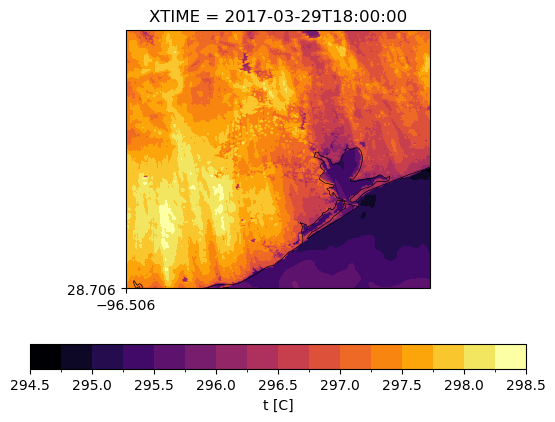

In [9]:
fig = plt.figure()
maplimits = [min_lon, max_lon, min_lat, max_lat]

# explicitly set up axis with projection
ax = plt.axes(projection=ccrs.PlateCarree())

# add coastlines
ax.coastlines(linewidths=0.5)
ax.set_extent([maplimits[0], maplimits[1],maplimits[2],maplimits[3]], ccrs.PlateCarree())

#2017 data
temp_basic = ds17.T2

temp_basic[0, :, :].plot.contourf(ax=ax,
                           transform=ccrs.PlateCarree(),
                           levels=20,
                           x = "XLONG", 
                           y="XLAT",
                           cmap="inferno",
                           cbar_kwargs={
                               "orientation": "horizontal",
                               "label": "t [K]"}
                            )

# configure axes
ax.set_xlabel("")
ax.set_xticks(np.arange(maplimits[0], maplimits[1], 10))

ax.set_ylabel("")
ax.set_yticks(np.arange(maplimits[2], maplimits[3], 10));

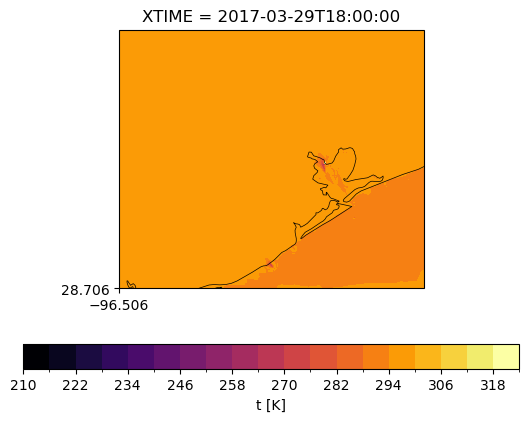

In [10]:
fig = plt.figure()
maplimits = [min_lon, max_lon, min_lat, max_lat]

# explicitly set up axis with projection
ax = plt.axes(projection=ccrs.PlateCarree())

# add coastlines
ax.coastlines(linewidths=0.5)
ax.set_extent([maplimits[0], maplimits[1],maplimits[2],maplimits[3]], ccrs.PlateCarree())

#Simulated 2017 data
temp_basic = ds17c.T2

temp_basic[0, :, :].plot.contourf(ax=ax,
                           transform=ccrs.PlateCarree(),
                           levels=20,
                           x = "XLONG", 
                           y="XLAT",
                           cmap="inferno",
                           cbar_kwargs={
                               "orientation": "horizontal",
                               "label": "t [K]"}
                            )

# configure axes
ax.set_xlabel("")
ax.set_xticks(np.arange(maplimits[0], maplimits[1], 10))

ax.set_ylabel("")
ax.set_yticks(np.arange(maplimits[2], maplimits[3], 10));

Now do the same thing but with general temperature

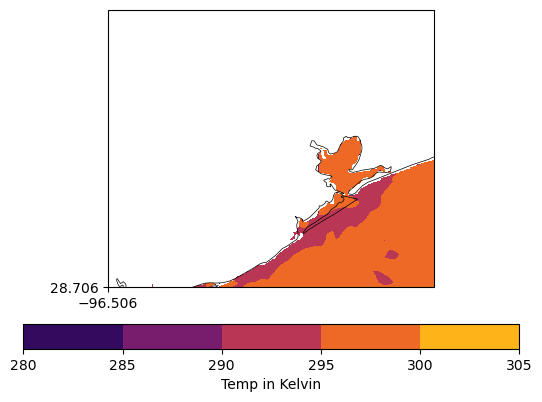

In [48]:
fig = plt.figure()
maplimits = [min_lon, max_lon, min_lat, max_lat]

# explicitly set up axis with projection
ax = plt.axes(projection=ccrs.PlateCarree())

# add coastlines
ax.coastlines(linewidths=0.5)
ax.set_extent([maplimits[0], maplimits[1],maplimits[2],maplimits[3]], ccrs.PlateCarree())

#2017 data
SST_basic = ds17.SST[0, :, :].values  # Ensure it's a 2D NumPy array
lons = ds17.XLONG[0, :, :].values
lats = ds17.XLAT[0, :, :].values


# Use proper bounds for color levels
cmap=mpl.cm.inferno
bounds = np.arange(280, 310, 5)  # Gives 265, 270, ..., 295
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

# Plot manually using plt.contourf
cf = ax.contourf(
    lons, lats, SST_basic,
    levels=bounds,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Add colorbar manually
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, ticks=bounds)
cbar.set_label("Temp in Kelvin")

# Set ticks
ax.set_xticks(np.arange(maplimits[0], maplimits[1], 3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(maplimits[2], maplimits[3], 3), crs=ccrs.PlateCarree())
ax.set_xlabel("")
ax.set_ylabel("")

plt.show()

In [36]:
print("Min:", SST_basic[0, :, :].min().item())
print("Max:", SST_basic[0, :, :].max().item())


Min: 0.0
Max: 296.549072265625


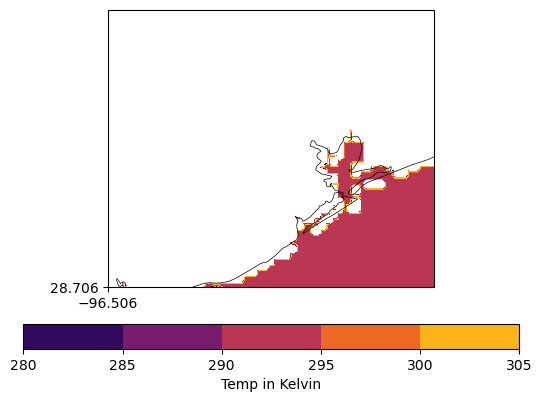

In [49]:
fig = plt.figure()
maplimits = [min_lon, max_lon, min_lat, max_lat]

# explicitly set up axis with projection
ax = plt.axes(projection=ccrs.PlateCarree())

# add coastlines
ax.coastlines(linewidths=0.5)
ax.set_extent([maplimits[0], maplimits[1],maplimits[2],maplimits[3]], ccrs.PlateCarree())

#Simulated 2017 data
SST_basic = ds17c.SST[0, :, :].values  # Ensure it's a 2D NumPy array
lons = ds17c.XLONG[0, :, :].values
lats = ds17c.XLAT[0, :, :].values


# Use proper bounds for color levels
cmap=mpl.cm.inferno
bounds = np.arange(280, 310, 5)  # Gives 265, 270, ..., 295
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

# Plot manually using plt.contourf
cf = ax.contourf(
    lons, lats, SST_basic,
    levels=bounds,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Add colorbar manually
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, ticks=bounds)
cbar.set_label("Temp in Kelvin")

# Set ticks
ax.set_xticks(np.arange(maplimits[0], maplimits[1], 3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(maplimits[2], maplimits[3], 3), crs=ccrs.PlateCarree())
ax.set_xlabel("")
ax.set_ylabel("")

plt.show()

Try to modify it a bit so it makes more sense - MODIFIED_IGBP_MODIS_NOAH

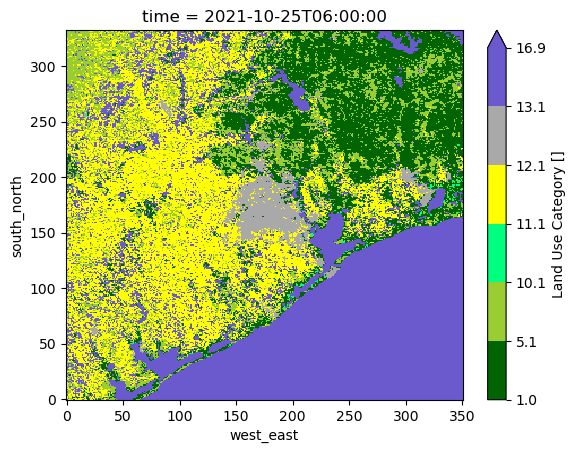

In [88]:
from matplotlib import colors

LU_nums = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
LU_names = ['Evergreen Needleleaf Forest', 'Evergreen Broadleaf Forest', 
            'Deciduous Needleleaf Forest', 'Deciduous Broadleaf Forest',
            'Mixed Forests', 'Closed Shrublands',  'Open Shrublands', 
            'Woody Savannas', 'Savannas', 'Grasslands', 
            'Permanent wetlands', 'Croplands', 'Urban and Built-Up', 
            'cropland/natural vegetation mosaic', 
            'Snow and Ice', 'Barren or Sparsely Vegetated', 'Water']

cmap = colors.ListedColormap(['darkgreen', 'yellowgreen', 'springgreen', 
                              'yellow', 'darkgray', 'tan', 'slateblue'])
bounds=[1,5.1, 10.1, 11.1,12.1, 13.1, 16.9]
norm = colors.BoundaryNorm(bounds, cmap.N)

lu_data = ds17.LU_INDEX

# tell imshow about color map so that only set colors are used
img = lu_data[0,:,:].plot.imshow(interpolation='nearest', origin='lower',
                    cmap=cmap, norm=norm)

plt.savefig('LandUse.png')

In [3]:
example_SST

<xarray.Dataset> Size: 415MB
Dimensions:           (time: 1, lat: 3600, lon: 7200)
Coordinates:
  * time              (time) datetime64[ns] 8B 2016-03-23T12:00:00
  * lat               (lat) float32 14kB -89.97 -89.93 -89.88 ... 89.93 89.97
  * lon               (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    analysed_sst      (time, lat, lon) float32 104MB ...
    analysis_error    (time, lat, lon) float32 104MB ...
    sea_ice_fraction  (time, lat, lon) float32 104MB ...
    mask              (time, lat, lon) float32 104MB ...
Attributes: (12/47)
    Conventions:                CF-1.4, ACDD-1.3
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    summary:                    A merged, multi-sensor L4 Foundation SST product
    references:                 Donlon, C.J., Martin, M., Stark, J.D., Robert...
    institution:                UKMO
    history:                    Created from sst.nc; obs_anal.nc; seaice.nc
    ...                         ...
    project:                    Group for High Resolution Sea Surface Tempera...
    publisher_name:             GHRSST Project Office
    publisher_url:              http://www.ghrsst.org
    publisher_email:            ghrsst-po@nceo.ac.uk
    processing_level:           L4
    cdm_data_type:              grid

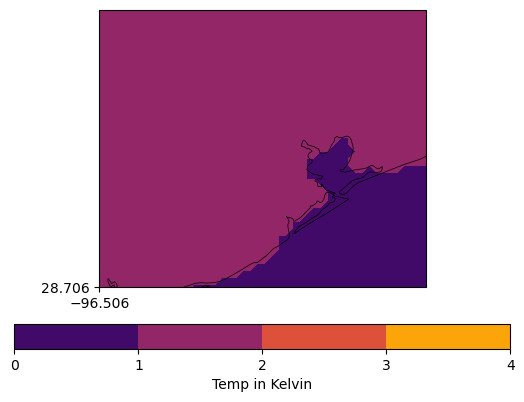

In [11]:
#Look at basic SST mask data to get a sense for it 
fig = plt.figure()
maplimits = [min_lon, max_lon, min_lat, max_lat]

# explicitly set up axis with projection
ax = plt.axes(projection=ccrs.PlateCarree())

# add coastlines
ax.coastlines(linewidths=0.5)
ax.set_extent([maplimits[0], maplimits[1],maplimits[2],maplimits[3]], ccrs.PlateCarree())

#2017 data
SST_mask = example_SST.mask[0,:,:]
lons = example_SST.lon
lats = example_SST.lat


# Use proper bounds for color levels
cmap=mpl.cm.inferno
bounds = np.arange(0, 5, 1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

# Plot manually using plt.contourf
cf = ax.contourf(
    lons, lats, SST_mask,
    levels=bounds,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Add colorbar manually
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, ticks=bounds)
cbar.set_label("Temp in Kelvin")
# configure axes
ax.set_xlabel("")
ax.set_xticks(np.arange(maplimits[0], maplimits[1], 10))

ax.set_ylabel("")
ax.set_yticks(np.arange(maplimits[2], maplimits[3], 10));